# **Credit Risk Scorecard Project**

This project builds a credit risk scorecard model to estimate the probability that a customer will default within two years.
The scorecard approach is widely used in banking because it provides both a probability of default (PD) and an interpretable credit score.



**Stage 1: Setup and Data Load**

In this stage, we prepare our environment and load the dataset.
We import the Python libraries we need, load the raw CSV into pandas, and take a first look at its shape and structure.

In [1]:
# pandas: our main tool for loading and manipulating tabular data
import pandas as pd
# sqlite3: Python's built-in library for talking to a SQLite database file
import sqlite3
# numpy: used later for numeric operations like log() when we calculate WoE
import numpy as np


We load the Give Me Some Credit dataset from Kaggle into a pandas DataFrame. This dataset contains information on customers, including whether they defaulted within two years.

In [8]:

file_path = '../data/cs-training.csv'

# Read the raw CSV into a pandas DataFrame - this is our main working object for the whole project
df = pd.read_csv(file_path)

# Show the first 5 rows so we can eyeball the columns and spot anything obviously wrong early
df.head()


,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


We check the shape of the dataset, i.e., the number of rows (customers) and columns (variables).

In [3]:
# .shape returns (rows, columns) - confirms we loaded all 150,000 customers and all 12 columns
df.shape


(150000, 12)

We list all column names to see what variables are included in the dataset.

In [4]:
# List every column name exactly as it appears in the CSV, so we know what we're working with
df.columns


Index(['Unnamed: 0', 'SeriousDlqin2yrs',
       'RevolvingUtilizationOfUnsecuredLines', 'age',
       'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome',
       'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate',
       'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse',
       'NumberOfDependents'],
      dtype='str')

We generate summary statistics (mean, median, min, max, etc.) for all numeric columns. This gives us a first look at the distributions and any obviously unusual values (e.g., a minimum age of 0, or utilization far above 1.0).

In [5]:
# Summary statistics (count, mean, std, min, quartiles, max) for every numeric column.
# This is our first chance to spot problems: e.g. a utilization max far above 1.0,
# or an age minimum of 0, both of which we will fix in Stage 3.
df.describe()


,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,1.202690e+05,150000.000000,150000.000000,150000.000000,150000.000000,146076.000000
mean,75000.500000,0.066840,6.048438,52.295207,0.421033,353.005076,6.670221e+03,8.452760,0.265973,1.018240,0.240387,0.757222
std,43301.414527,0.249746,249.755371,14.771866,4.192781,2037.818523,1.438467e+04,5.145951,4.169304,1.129771,4.155179,1.115086
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,37500.750000,0.000000,0.029867,41.000000,0.000000,0.175074,3.400000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,75000.500000,0.000000,0.154181,52.000000,0.000000,0.366508,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,112500.250000,0.000000,0.559046,63.000000,0.000000,0.868254,8.249000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,150000.000000,1.000000,50708.000000,109.000000,98.000000,329664.000000,3.008750e+06,58.000000,98.000000,54.000000,98.000000,20.000000


We rename the unnamed index column to `ID` for clarity. This makes the dataset easier to work with, especially when saving it to SQL.

In [6]:
# The first column has no header in the raw CSV, so pandas names it 'Unnamed: 0'.
# It's really just a customer ID, so we rename it to something meaningful.
df.rename(columns={'Unnamed: 0': 'ID'}, inplace=True)

# Print the column list again to confirm the rename worked
print(df.columns.tolist())


['ID', 'SeriousDlqin2yrs', 'RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents']


We create a connection to a SQLite database file and save the dataset into it as a table named `credit_data`.
This gives us a simple, file-based database we can run SQL queries against in Stage 2.

In [7]:
# Path to the SQLite database file we're about to create (also relative, sits in data/)
db_file_path = '../data/credit_data.db'

# Open (or create, if it doesn't exist yet) the SQLite database file
conn = sqlite3.connect(db_file_path)

# Write the DataFrame into a table called "credit_data" inside that database.
# if_exists="replace" means: if we re-run this cell, overwrite the old table instead of erroring out.
# index=False means: don't write pandas' own row index as an extra column - we already have ID.
df.to_sql("credit_data", conn, if_exists="replace", index=False)

print("Saved", len(df), "rows to table 'credit_data' in", db_file_path)


Saved 150000 rows to table 'credit_data' in ../data/credit_data.db


**Stage 1 Summary**

In this stage we successfully:
- Imported the necessary Python libraries
- Loaded the Give Me Some Credit dataset into pandas, using a relative path so the notebook is portable
- Checked the dataset size, column names, and summary statistics
- Renamed the index column to `ID` for clarity
- Saved the dataset into a SQLite database for the SQL-based EDA in Stage 2

At this point, our dataset is properly loaded and ready for further exploration.

**Stage 2: SQL-based Exploratory Data Analysis**

Now that the data is loaded into our SQLite database, we use SQL to understand what is in the table and to check a few basic quality signals before cleaning anything.

We list the table schema. This shows every column in `credit_data` with its position and type so we know exactly what fields we are working with.

In [8]:
# PRAGMA table_info is a SQLite command that lists every column in a table,
# along with its position and inferred type - a quick way to confirm the table matches our DataFrame.
schema = pd.read_sql("PRAGMA table_info(credit_data);", conn)
print(schema)


    cid                                  name     type  notnull dflt_value  pk
0     0                                    ID  INTEGER        0       None   0
1     1                      SeriousDlqin2yrs  INTEGER        0       None   0
2     2  RevolvingUtilizationOfUnsecuredLines     REAL        0       None   0
3     3                                   age  INTEGER        0       None   0
4     4  NumberOfTime30-59DaysPastDueNotWorse  INTEGER        0       None   0
5     5                             DebtRatio     REAL        0       None   0
6     6                         MonthlyIncome     REAL        0       None   0
7     7       NumberOfOpenCreditLinesAndLoans  INTEGER        0       None   0
8     8               NumberOfTimes90DaysLate  INTEGER        0       None   0
9     9          NumberRealEstateLoansOrLines  INTEGER        0       None   0
10   10  NumberOfTime60-89DaysPastDueNotWorse  INTEGER        0       None   0
11   11                    NumberOfDependents     RE

We preview five rows for key fields: the ID, the target flag `SeriousDlqin2yrs`, utilization, and age. This sanity-checks that the table loaded correctly.

In [9]:
# Pull just 5 rows and a handful of key columns, straight from SQL this time (not pandas),
# to confirm the SQLite table holds the same data as our DataFrame.
check = pd.read_sql(
    "SELECT ID, SeriousDlqin2yrs, RevolvingUtilizationOfUnsecuredLines, age FROM credit_data LIMIT 5;",
    conn
)
print(check)


   ID  SeriousDlqin2yrs  RevolvingUtilizationOfUnsecuredLines  age
0   1                 1                              0.766127   45
1   2                 0                              0.957151   40
2   3                 0                              0.658180   38
3   4                 0                              0.233810   30
4   5                 0                              0.907239   49


We count how many rows are in the table. This confirms the dataset size we are working with.

In [10]:
# COUNT(*) simply counts every row in the table - should match df.shape[0] from Stage 1
pd.read_sql("SELECT COUNT(*) as total_rows from credit_data;", conn)


,total_rows
0,150000


We calculate the overall default rate. The query counts how many customers are non-default (0) and default (1), and reports each as a percentage of the total.

In [11]:
# Group by the target column (0 = no default, 1 = default) and count how many customers
# fall into each group, then convert that count into a percentage of the whole table.
# This gives us the overall default rate before we touch the data at all.
pd.read_sql(""" SELECT SeriousDlqin2yrs, COUNT(*) as count,
round(100.0 * count(*) / (select count(*) from credit_data), 2) as percent
from credit_data
group by SeriousDlqin2yrs;""", conn)


,SeriousDlqin2yrs,count,percent
0,0,139974,93.32
1,1,10026,6.68


We check the top five records by utilization. This helps us spot extreme or unusual values that may need capping in Stage 3.

In [12]:
# Sort by utilization descending and look at the top 5 - if utilization is a genuine ratio
# it should be roughly 0 to 1, so any huge values here confirm we need to cap it in Stage 3.
pd.read_sql("""
SELECT ID, RevolvingUtilizationOfUnsecuredLines, age
FROM credit_data
ORDER BY RevolvingUtilizationOfUnsecuredLines DESC
LIMIT 5;
""", conn)


,ID,RevolvingUtilizationOfUnsecuredLines,age
0,85490,50708.0,55
1,31415,29110.0,58
2,16957,22198.0,38
3,149161,22000.0,38
4,149280,20514.0,42


We summarize age with minimum, maximum, and average. This catches clearly invalid values such as age equal to zero.

In [13]:
# MIN/MAX/AVG on age in one query - catches obviously invalid ages (e.g. 0) at a glance.
pd.read_sql("""
SELECT MIN(age) as min_age, MAX(age) as max_age, AVG(age) as avg_age
from credit_data;
""", conn)


,min_age,max_age,avg_age
0,0,109,52.295207


We count missing values in `MonthlyIncome` and `NumberOfDependents`. This tells us how much imputation we will need to do in Stage 3.

In [14]:
# SUM(CASE WHEN ... THEN 1 ELSE 0 END) is SQL's way of counting rows that meet a condition.
# Here we count how many rows have a NULL (missing) MonthlyIncome or NumberOfDependents,
# so we know exactly how much imputation Stage 3 needs to do.
pd.read_sql("""
SELECT
SUM(CASE WHEN MonthlyIncome is NULL THEN 1 ELSE 0 END) as missing_income,
SUM(CASE WHEN NumberOfDependents is NULL THEN 1 ELSE 0 END) as missing_dependents
from credit_data;
""", conn)


,missing_income,missing_dependents
0,29731,3924


We tabulate how many customers have been 30–59, 60–89, and 90+ days past due. This shows the distribution of delinquency severity across the portfolio.

In [15]:
# Loop over the three delinquency columns and run the same "count per value" query for each,
# rather than writing the same query three times by hand.
# col = the actual column name in the table, label = a friendly name just for the printout.
for col, label in [
    ("NumberOfTime30-59DaysPastDueNotWorse", "30-59 days late"),
    ("NumberOfTime60-89DaysPastDueNotWorse", "60-89 days late"),
    ("NumberOfTimes90DaysLate", "90+ days late"),
]:
    print(f"--- {label} ---")
    # Column names with dashes need double quotes in SQL, hence the "{col}" inside the f-string
    print(pd.read_sql(f'SELECT "{col}" AS bucket, COUNT(*) as count FROM credit_data GROUP BY "{col}" ORDER BY bucket;', conn))
    print()


--- 30-59 days late ---


    bucket   count
0        0  126018
1        1   16033
2        2    4598
3        3    1754
4        4     747
5        5     342
6        6     140
7        7      54
8        8      25
9        9      12
10      10       4
11      11       1
12      12       2
13      13       1
14      96       5
15      98     264

--- 60-89 days late ---
    bucket   count
0        0  142396
1        1    5731
2        2    1118
3        3     318
4        4     105
5        5      34
6        6      16
7        7       9
8        8       2
9        9       1
10      11       1
11      96       5
12      98     264

--- 90+ days late ---
    bucket   count
0        0  141662
1        1    5243
2        2    1555
3        3     667
4        4     291
5        5     131
6        6      80
7        7      38
8        8      21
9        9      19
10      10       8
11      11       5
12      12       2
13      13       4
14      14       2
15      15       2
16      17       1
17      96       5
18

We count how many customers have zero, one, two, or more dependents. This gives context for the missing dependent values before we impute them.

In [16]:
# Count how many customers have 0, 1, 2, ... dependents.
# Useful context before we decide how to fill the missing dependents values in Stage 3.
pd.read_sql("""
SELECT NumberOfDependents as dependents, COUNT(*) as count
from credit_data
GROUP BY NumberOfDependents
ORDER BY dependents;
""", conn)


,dependents,count
0,NaN,3924
1,0.0,86902
2,1.0,26316
3,2.0,19522
4,3.0,9483
5,4.0,2862
6,5.0,746
7,6.0,158
8,7.0,51
9,8.0,24


**Stage 2 Summary**

- We confirmed the table structure, counted rows, and measured the overall default rate (~6.7%).
- We scanned age and utilization for unusual values (utilization values well above 1.0, which is not possible for a genuine ratio).
- We quantified missing income and dependents so we know how much imputation is needed.
- We profiled delinquency counts across the 30–59, 60–89, and 90+ day buckets, and reviewed the dependents distribution.

These findings guide the next stage, where we clean the data, cap outliers, and create business-friendly bins for modelling.

**Stage 3: Data Cleaning and Feature Engineering**

In this stage we improve data quality and prepare features for modeling.
From the SQL analysis we know there are missing values in `MonthlyIncome` and `NumberOfDependents`, and outliers in age, utilization, and the delinquency counters.

**A methodology note before we start:** the steps below fall into two different categories, and the order they're applied in matters:
- Outlier caps (age floor, utilization cap, delinquency caps) are **fixed business rules** — they don't depend on the data's target values, so applying them before the train/test split is safe.
- The median used for income imputation, and the WoE tables used for feature encoding, **are derived from the data itself**, including the target. Computing them on the full dataset before splitting would leak information from the test set into training — a common but easy-to-miss mistake in scorecard projects. So below we apply the business-rule caps first, **then split into train/test, then compute the median and WoE tables using the training data only**, and apply those same values to the test set.


We fix invalid ages by setting any age below eighteen to eighteen, so the dataset reflects realistic adult customers. This is a fixed rule, not derived from the data, so it's safe to apply before splitting.

In [17]:
# .loc[condition, column] = value : for every row where age < 18, overwrite age with 18.
# This is a fixed business rule (not derived from the data), so it's safe to apply before splitting.
df.loc[df["age"] < 18, "age"] = 18

# Confirm the fix worked: this should now print 0
print("Age < 18 now:", (df["age"] < 18).sum())


Age < 18 now: 0


We cap credit utilization at one hundred percent so extreme values (a ratio can't sensibly exceed 100%) do not distort the model. Also a fixed rule.

In [18]:
# Same pattern as the age fix: cap any utilization ratio above 1.0 (100%) down to exactly 1.0,
# since a ratio can't sensibly exceed 100% and values above that are almost certainly data errors.
df.loc[df["RevolvingUtilizationOfUnsecuredLines"] > 1, "RevolvingUtilizationOfUnsecuredLines"] = 1.0

# Confirm: should now print 0
print("Utilization > 1 now:", (df["RevolvingUtilizationOfUnsecuredLines"] > 1).sum())


Utilization > 1 now: 0


We cap the three delinquency counters (30-59, 60-89, 90+ days late) at ten, to limit the influence of a handful of extreme outliers, and cap dependents at six for the same reason.

In [19]:
# .clip(upper=10) caps any value above 10 down to 10, leaving everything else untouched.
# Loop over all three delinquency counters so we don't repeat the same line three times.
for col in ["NumberOfTime30-59DaysPastDueNotWorse", "NumberOfTime60-89DaysPastDueNotWorse", "NumberOfTimes90DaysLate"]:
    df[col] = df[col].clip(upper=10)

# Same idea for number of dependents, just with a different cap (6 instead of 10)
df["NumberOfDependents"] = df["NumberOfDependents"].clip(upper=6)

# Print the new maximums to confirm every cap actually took effect
print("Max 30-59 late:", df["NumberOfTime30-59DaysPastDueNotWorse"].max())
print("Max 60-89 late:", df["NumberOfTime60-89DaysPastDueNotWorse"].max())
print("Max 90+ late:", df["NumberOfTimes90DaysLate"].max())
print("Max dependents:", df["NumberOfDependents"].max())


Max 30-59 late: 10
Max 60-89 late: 10
Max 90+ late: 10
Max dependents: 6.0


**Train/test split happens here — before any statistic derived from the data (median income, WoE tables) is calculated.**
We hold out 30% of the data, stratified on the target so both sets have a similar default rate.

In [20]:
from sklearn.model_selection import train_test_split

# Split into 70% train / 30% test.
# stratify=df["SeriousDlqin2yrs"] tells sklearn to keep the default rate roughly equal
# in both halves, instead of risking an unlucky split with very different default rates.
# random_state=42 just makes the split reproducible - same split every time we re-run this cell.
#
# IMPORTANT: this split happens BEFORE we compute anything derived from the data itself
# (median income, WoE tables) so that those calculations only ever see the training rows.
train_df, test_df = train_test_split(
    df, test_size=0.3, random_state=42, stratify=df["SeriousDlqin2yrs"]
)

# .copy() avoids a "SettingWithCopyWarning" later when we start adding new columns to these
train_df = train_df.copy()
test_df = test_df.copy()

print(f"Train rows: {len(train_df):,}  |  Test rows: {len(test_df):,}")
# Confirm stratify worked: these two percentages should be very close to each other
print(f"Train default rate: {train_df['SeriousDlqin2yrs'].mean()*100:.2f}%  |  Test default rate: {test_df['SeriousDlqin2yrs'].mean()*100:.2f}%")


Train rows: 105,000  |  Test rows: 45,000
Train default rate: 6.68%  |  Test default rate: 6.68%


We compute the median `MonthlyIncome` **from the training set only**, and use that same value to fill missing incomes in both train and test. This keeps the test set genuinely unseen during preparation.

In [21]:
# Compute the median income using ONLY the training rows - this is the key leakage fix.
# If we computed this on the full dataset (train + test combined), the test set would be
# influencing a value used to prepare data the model is later judged on.
median_income = train_df["MonthlyIncome"].median()
print("Median income (from train only):", median_income)

# Apply that SAME training-derived median to fill missing incomes in both train and test.
# Test never contributes its own values here - it only receives the number train produced.
train_df["MonthlyIncome"] = train_df["MonthlyIncome"].fillna(median_income)
test_df["MonthlyIncome"] = test_df["MonthlyIncome"].fillna(median_income)


Median income (from train only): 5382.0


We fill missing `NumberOfDependents` with zero — a simple, transparent rule (also the most common value in this data), applied to both sets.

In [22]:
# Filling missing dependents with a constant (0) doesn't involve any data-derived statistic,
# so there's no leakage risk here either way - but we still do it separately per set for clarity.
train_df["NumberOfDependents"] = train_df["NumberOfDependents"].fillna(0)
test_df["NumberOfDependents"] = test_df["NumberOfDependents"].fillna(0)

# Double check: both of these should now print 0 missing values
print(train_df[["MonthlyIncome", "NumberOfDependents"]].isnull().sum())
print(test_df[["MonthlyIncome", "NumberOfDependents"]].isnull().sum())


MonthlyIncome         0
NumberOfDependents    0
dtype: int64
MonthlyIncome         0
NumberOfDependents    0
dtype: int64


We create age and utilization bins using fixed, business-friendly edges — the same edges are simply applied to both train and test (no leakage risk, since the edges aren't derived from the data).
Income bins are different: they come from `qcut`, which *is* data-derived (it picks edges based on the training data's quantiles), so we compute the edges on train only and reuse those exact edges on test.

In [23]:
# Fixed, business-friendly bin edges for age and utilization.
# These edges are hand-picked, not derived from the data's distribution, so applying the
# exact same edges to both train and test carries no leakage risk.
age_bins = [18, 25, 35, 45, 55, 65, 120]
age_labels = ["18-25", "26-35", "36-45", "46-55", "56-65", "66+"]

util_bins = [0.0, 0.10, 0.30, 0.60, 1.00]
util_labels = ["0-10%", "10-30%", "30-60%", "60-100%"]

# Loop over both DataFrames and apply the SAME fixed edges to each.
# pd.cut() slices a numeric column into the bins we specify and labels each row accordingly.
# include_lowest=True makes sure a value exactly equal to the very first edge (e.g. age=18) is included.
for d in [train_df, test_df]:
    d["age_bin"] = pd.cut(d["age"], bins=age_bins, labels=age_labels, include_lowest=True)
    d["util_bin"] = pd.cut(d["RevolvingUtilizationOfUnsecuredLines"], bins=util_bins,
                             labels=util_labels, include_lowest=True)

# Income is different: pd.qcut() picks bin edges based on the DATA's own quantiles (e.g. "20% of
# incomes fall below X"), so those edges themselves are data-derived and must come from train only.
# retbins=True asks qcut to also hand back the numeric edges it chose, so we can reuse them.
train_df["income_bin"], income_bin_edges = pd.qcut(
    train_df["MonthlyIncome"], q=5, duplicates="drop", retbins=True
)

income_bin_edges = income_bin_edges.copy()
# Stretch the outer edges to +/- infinity so that any test-set income lower or higher than
# anything seen in train still falls inside a bin, instead of becoming an unbinned NaN.
income_bin_edges[0] = -np.inf   # so no test-set income below train's min falls outside the bins
income_bin_edges[-1] = np.inf   # same for incomes above train's max

# Apply those exact train-derived edges to the test set with plain pd.cut() (not qcut, since
# we already have fixed edges now - qcut would recompute new edges from test's own data, which
# is exactly the leakage we're trying to avoid).
test_df["income_bin"] = pd.cut(test_df["MonthlyIncome"], bins=income_bin_edges)

# Sanity-check the bin counts for all three variables
print(train_df["age_bin"].value_counts(dropna=False).sort_index())
print()
print(train_df["income_bin"].value_counts(dropna=False).sort_index())
print()
print(train_df["util_bin"].value_counts(dropna=False).sort_index())


age_bin
18-25     2169
26-35    12821
36-45    20947
46-55    25658
56-65    23513
66+      19892
Name: count, dtype: int64

income_bin
(-0.001, 3400.0]       21269
(3400.0, 5350.6]       20731
(5350.6, 5400.0]       21163
(5400.0, 8250.0]       20866
(8250.0, 1794060.0]    20971
Name: count, dtype: int64

util_bin
0-10%      45182
10-30%     19780
30-60%     15343
60-100%    24695
Name: count, dtype: int64


**Feature screening: is age/income/utilization actually the right choice of three variables?**

Before committing to age, income, and utilization, we compute Information Value for *every* candidate numeric variable (using the training set only), so the choice of features is evidence-based rather than assumed. IV rule of thumb: <0.02 useless, 0.02–0.1 weak, 0.1–0.3 medium, 0.3–0.5 strong, >0.5 very strong (and worth double-checking for over-fitting / near-perfect separation).

In [24]:
# Quick, rough IV calculation - simpler than the full build_woe_table() function below,
# because here we just want a single number per variable to RANK and compare all 10 candidates,
# not a full bin-by-bin breakdown.
def quick_iv(data, feature, target="SeriousDlqin2yrs", bins=5):
    series = data[feature]

    # Decide how to bin this variable before computing WoE/IV on it:
    if series.nunique() > 15:
        # Genuinely continuous variables (income, debt ratio, ...) get split into quantile bins.
        binned = pd.qcut(series, q=bins, duplicates="drop")
    else:
        # Skewed count variables (delinquency counters etc.) have few unique values (e.g. 0-10).
        # Using qcut on these is a trap: because most customers have a value of 0, the quantile
        # edges collapse and qcut can return a SINGLE bin covering the whole variable - which
        # silently produces IV = 0 and makes a genuinely strong predictor look useless.
        # So for anything with 15 or fewer unique values, we just use the raw values as "bins".
        binned = series

    # From here on it's the standard IV formula: count goods/bads per bin, turn those into
    # shares of the total good/bad population, then WoE = ln(share of good / share of bad).
    g = data.groupby(binned, observed=True)[target].agg(["count", "sum"])
    g.columns = ["n", "bad"]
    g["good"] = g["n"] - g["bad"]
    total_good, total_bad = g["good"].sum(), g["bad"].sum()
    EPS = 1e-6  # tiny constant so we never divide by zero or take log(0)
    dist_good = g["good"] / max(total_good, EPS)
    dist_bad = g["bad"] / max(total_bad, EPS)
    woe = np.log(dist_good.clip(lower=EPS) / dist_bad.clip(lower=EPS)).replace([np.inf, -np.inf], 0.0)
    # IV per bin = (difference in share of good vs bad) x WoE; summing these gives the variable's total IV
    iv = ((dist_good - dist_bad) * woe).sum()
    return iv

# Every numeric candidate variable in the dataset except the ID and the target itself
candidate_features = [
    "RevolvingUtilizationOfUnsecuredLines", "age", "NumberOfTime30-59DaysPastDueNotWorse",
    "DebtRatio", "MonthlyIncome", "NumberOfOpenCreditLinesAndLoans", "NumberOfTimes90DaysLate",
    "NumberRealEstateLoansOrLines", "NumberOfTime60-89DaysPastDueNotWorse", "NumberOfDependents"
]

# Compute IV for every candidate (on TRAIN only, same leakage-avoidance rule as everywhere else),
# then sort so the strongest predictors surface at the top.
iv_screen = pd.DataFrame({
    "feature": candidate_features,
    "information_value": [quick_iv(train_df, f) for f in candidate_features]
}).sort_values("information_value", ascending=False).reset_index(drop=True)

iv_screen


,feature,information_value
0,RevolvingUtilizationOfUnsecuredLines,1.060289
1,NumberOfTimes90DaysLate,0.897045
2,NumberOfTime30-59DaysPastDueNotWorse,0.743533
3,NumberOfTime60-89DaysPastDueNotWorse,0.603817
4,age,0.233511
5,MonthlyIncome,0.070517
6,DebtRatio,0.065508
7,NumberOfOpenCreditLinesAndLoans,0.048790
8,NumberOfDependents,0.032999
9,NumberRealEstateLoansOrLines,0.013018


**What this tells us:** utilization and the delinquency counters (especially `NumberOfTimes90DaysLate`) carry the strongest signal in this dataset — often stronger than age or income.
For this project we're deliberately keeping the scorecard to **three variables (age, income, utilization)** to keep the WoE → scorecard walkthrough easy to follow end-to-end, and utilization is genuinely the strongest of the three by IV. Age and income are kept for interpretability and because they're the variables a loan officer would explain to a customer face-to-face. `NumberOfTimes90DaysLate` and the other delinquency counters are the natural next features to add if the scorecard were being extended for production use — noted here explicitly rather than left unexplained.

**Weight of Evidence (WoE) and Information Value (IV) for the chosen features**

Same formulas as before — WoE = ln(dist_good / dist_bad) per bin, IV = sum of (dist_good − dist_bad) × WoE across bins — but now computed **on `train_df` only**. The resulting WoE tables are then mapped onto both `train_df` and `test_df`, so the test set never contributes to the WoE values it's later scored with.

In [25]:
# This is the "real", detailed version of the WoE/IV calculation - same formula as quick_iv()
# above, but returns the full bin-by-bin table (not just a single IV number), because we need
# these per-bin WoE values later to build the actual points scorecard.
def build_woe_table(data, bin_col, target="SeriousDlqin2yrs"):
    # Step 1: count total customers, and how many are bad (defaulted), per bin
    g = data.groupby(bin_col, observed=True)[target].agg(["count", "sum"])
    g.columns = ["n", "bad_count"]
    g["good_count"] = g["n"] - g["bad_count"]
    g["bad_rate"] = g["bad_count"] / g["n"]  # within-bin default rate, just for readability

    # Step 2: convert each bin's good/bad counts into a SHARE of the total good/bad population
    total_good = g["good_count"].sum()
    total_bad = g["bad_count"].sum()
    EPS = 1e-6
    g["dist_good"] = g["good_count"] / max(total_good, EPS)
    g["dist_bad"] = g["bad_count"] / max(total_bad, EPS)

    # Step 3: WoE = ln(share of good / share of bad).
    # Positive WoE = bin is safer than average; negative WoE = bin is riskier than average.
    g["woe"] = np.log(g["dist_good"].clip(lower=EPS) / g["dist_bad"].clip(lower=EPS))
    g["woe"] = g["woe"].replace([np.inf, -np.inf], 0.0)  # neutral evidence if a bin has 0 good or 0 bad

    # Step 4: IV contribution of each bin = (difference in good/bad share) x WoE.
    # Summing this column gives the variable's total Information Value.
    g["iv_bin"] = (g["dist_good"] - g["dist_bad"]) * g["woe"]

    return g.reset_index()

# Build one WoE table per chosen feature - all fit on train_df only
util_detail = build_woe_table(train_df, "util_bin")
age_detail = build_woe_table(train_df, "age_bin")
income_detail = build_woe_table(train_df, "income_bin")

# .sum() across the iv_bin column gives the total IV for that whole variable
util_iv_total = util_detail["iv_bin"].sum()
age_iv_total = age_detail["iv_bin"].sum()
income_iv_total = income_detail["iv_bin"].sum()

print("--- Utilization ---")
print(util_detail[["util_bin", "n", "bad_rate", "woe", "iv_bin"]])
print(f"Total IV (utilization): {util_iv_total:.4f}\n")

print("--- Age ---")
print(age_detail[["age_bin", "n", "bad_rate", "woe", "iv_bin"]])
print(f"Total IV (age): {age_iv_total:.4f}\n")

print("--- Income ---")
print(income_detail[["income_bin", "n", "bad_rate", "woe", "iv_bin"]])
print(f"Total IV (income): {income_iv_total:.4f}")


--- Utilization ---
  util_bin      n  bad_rate       woe    iv_bin
0    0-10%  45182  0.018481  1.336063  0.445742
1   10-30%  19780  0.029676  0.850971  0.095514
2   30-60%  15343  0.067457 -0.009888  0.000014
3  60-100%  24695  0.184693 -1.151437  0.511714
Total IV (utilization): 1.0530

--- Age ---
  age_bin      n  bad_rate       woe    iv_bin
0   18-25   2169  0.107884 -0.523764  0.007120
1   26-35  12821  0.109040 -0.535719  0.044261
2   36-45  20947  0.088079 -0.298992  0.020314
3   46-55  25658  0.075376 -0.129409  0.004329
4   56-65  23513  0.047378  0.364754  0.025485
5     66+  19892  0.024784  1.036162  0.132357
Total IV (age): 0.2339

--- Income ---
            income_bin      n  bad_rate       woe    iv_bin
0     (-0.001, 3400.0]  21269  0.091871 -0.345302  0.028073
1     (3400.0, 5350.6]  20731  0.079736 -0.190361  0.007772
2     (5350.6, 5400.0]  21163  0.054954  0.208424  0.008004
3     (5400.0, 8250.0]  20866  0.060912  0.099165  0.001872
4  (8250.0, 1794060.0]  2097

**A note on the utilization IV:** at ~1.0+ it sits above the conventional 0.5 "very strong / double-check for over-fitting" threshold. We checked this isn't a leakage artifact — it's computed purely from `RevolvingUtilizationOfUnsecuredLines` bins on the training set, with no target information mixed in — so it reflects a genuinely strong raw relationship in this dataset (utilization is well known to be one of the single strongest predictors in Give Me Some Credit). It's called out here rather than left silent, since a reviewer would reasonably ask about it.

We map each bin's WoE value onto every customer, in both `train_df` and `test_df`, using dictionaries built from the training-set WoE tables above. Any bin that appears in test but not in train (there shouldn't be any here, since bin edges are shared) would map to `NaN` and get filled with 0.0 (neutral evidence).

In [26]:
# Build a lookup dictionary per variable: {bin label -> WoE value}, straight from the
# train-only WoE tables we just built above.
util_woe_map = dict(zip(util_detail["util_bin"], util_detail["woe"]))
age_woe_map = dict(zip(age_detail["age_bin"], age_detail["woe"]))
income_woe_map = dict(zip(income_detail["income_bin"], income_detail["woe"]))

# Apply each dictionary to BOTH train_df and test_df.
# Test rows only ever look up a WoE value that was computed from train - they never
# contribute to what that WoE value actually is.
# pd.to_numeric(..., errors="coerce") converts the mapped result to a plain float column and
# turns any unmapped bin into NaN, which we then replace with 0.0 (neutral evidence) below.
for d in [train_df, test_df]:
    d["util_woe"] = pd.to_numeric(d["util_bin"].map(util_woe_map), errors="coerce").fillna(0.0)
    d["age_woe"] = pd.to_numeric(d["age_bin"].map(age_woe_map), errors="coerce").fillna(0.0)
    d["income_woe"] = pd.to_numeric(d["income_bin"].map(income_woe_map), errors="coerce").fillna(0.0)

# Since train and test share the exact same bin edges, this should print 0 for every variable -
# confirming no test-set row silently fell outside a bin train never saw.
print("Any unmapped bins in test set (would show as non-zero counts below if bin edges didn't match):")
print("util:", test_df["util_bin"].isna().sum(), " age:", test_df["age_bin"].isna().sum(), " income:", test_df["income_bin"].isna().sum())

train_df[["util_woe", "age_woe", "income_woe"]].describe()


Any unmapped bins in test set (would show as non-zero counts below if bin edges didn't match):
util: 0  age: 0  income: 0


,util_woe,age_woe,income_woe
count,105000.000000,105000.000000,105000.000000
mean,0.462969,0.110476,0.030559
std,1.001019,0.532564,0.265119
min,-1.151437,-0.535719,-0.345302
25%,-0.009888,-0.298992,-0.190361
50%,0.850971,-0.129409,0.099165
75%,1.336063,0.364754,0.208424
max,1.336063,1.036162,0.382395


**Stage 3 Summary**

At the end of this stage:
- Fixed business-rule caps were applied first (age floor 18, utilization capped at 100%, delinquency counters capped at 10, dependents capped at 6)
- The data was then split into train (70%) and test (30%), stratified on the target
- Missing `MonthlyIncome` was filled with the **training-set** median; missing dependents were set to zero — applied identically to both sets
- Age, income, and utilization were binned (age/utilization on fixed edges, income on train-derived quantile edges)
- An Information Value screen across all 10 candidate variables was used to justify keeping age, income, and utilization, while noting that delinquency history carries even stronger signal
- WoE and IV were computed **on the training set only** and mapped onto both train and test, avoiding the leakage that comes from fitting these on the full dataset before splitting

The dataset is now clean, consistent, and transformed into model-ready features — with training and test sets kept properly separate throughout.

**Stage 4: Build Scorecard Model**

In this stage we build the actual credit risk scorecard model.
We use logistic regression on the WoE-transformed features to predict the probability of default, trained on `train_df` and evaluated on the held-out `test_df`.

In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, classification_report
import matplotlib.pyplot as plt

# The three WoE columns are the only inputs the model sees - not the raw age/income/utilization
woe_features = ["util_woe", "age_woe", "income_woe"]

# X = the features the model learns from, y = the target it's trying to predict
X_train, y_train = train_df[woe_features], train_df["SeriousDlqin2yrs"].astype(int)
X_test, y_test = test_df[woe_features], test_df["SeriousDlqin2yrs"].astype(int)

# max_iter=1000 just gives the optimizer enough iterations to converge reliably
clf = LogisticRegression(max_iter=1000, solver="lbfgs")
clf.fit(X_train, y_train)  # fit ONLY on training data

# predict_proba returns two columns: probability of class 0, probability of class 1.
# We only want the probability of default (class 1), hence [:, 1].
y_pred_proba = clf.predict_proba(X_test)[:, 1]

# AUC measures ranking quality across every possible threshold at once - the model never
# gets to see y_test's labels except through this evaluation step.
auc = roc_auc_score(y_test, y_pred_proba)

# Lay out each feature's fitted coefficient next to its name, sorted so we can read direction
# and relative strength at a glance (more negative = pushes the score down more per unit of WoE)
coef_table = pd.DataFrame({
    "feature": woe_features,
    "coefficient": clf.coef_[0]
}).sort_values("coefficient", ascending=False)

print(f"AUC on held-out test set: {auc:.3f}")
print("\nModel Coefficients:")
print(coef_table)


AUC on held-out test set: 0.781

Model Coefficients:
      feature  coefficient
1     age_woe    -0.470036
2  income_woe    -0.481114
0    util_woe    -0.935002


**ROC curve**

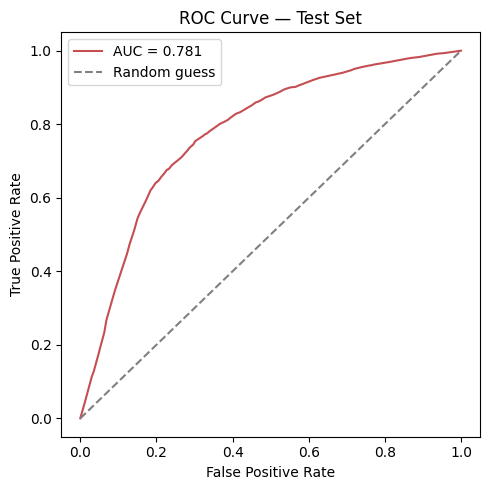

In [28]:
# roc_curve() sweeps through every possible threshold and returns the False Positive Rate (fpr)
# and True Positive Rate (tpr) at each one - that's literally what "ROC curve" means.
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(5, 5))
# Our model's curve - the more it bows toward the top-left corner, the better it separates classes
plt.plot(fpr, tpr, color="#C44E52", label=f"AUC = {auc:.3f}")
# The diagonal dashed line is what a model with zero skill (pure random guessing) would look like
plt.plot([0, 1], [0, 1], linestyle="--", color="grey", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Test Set")
plt.legend()
plt.tight_layout()
plt.show()


**Cutoff / threshold comparison.** A probability model outputs a continuous score between 0 and 1; turning that into an approve/reject decision requires picking a threshold. We compare a few thresholds below so the cutoff is a deliberate, evidence-based choice rather than defaulting to 0.50 untested.

In [29]:
# Try a handful of candidate probability cutoffs and see how each one performs,
# instead of blindly trusting the default 0.50 threshold.
thresholds_to_test = [0.50, 0.30, 0.20, 0.10, 0.07]
threshold_rows = []

for t in thresholds_to_test:
    # Turn probabilities into a hard 0/1 prediction: "predict default" if probability >= t
    preds = (y_pred_proba >= t).astype(int)

    # confusion_matrix returns a 2x2 grid: [[true_neg, false_pos], [false_neg, true_pos]]
    # .ravel() flattens that grid into four separate numbers we can use directly
    cm = confusion_matrix(y_test, preds)
    tn, fp, fn, tp = cm.ravel()

    # precision: of everyone WE FLAGGED as a default, what fraction actually defaulted?
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    # recall: of everyone who ACTUALLY defaulted, what fraction did we correctly flag?
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    # accuracy: fraction of ALL predictions (both classes) that were correct
    accuracy = (tp + tn) / (tp + tn + fp + fn)

    threshold_rows.append({
        "threshold": t, "accuracy": round(accuracy, 3),
        "precision_default": round(precision, 3), "recall_default": round(recall, 3),
        "flagged_as_default": int(preds.sum())
    })

threshold_table = pd.DataFrame(threshold_rows)
threshold_table


,threshold,accuracy,precision_default,recall_default,flagged_as_default
0,0.50,0.933,0.000,0.000,0
1,0.30,0.933,0.000,0.000,0
2,0.20,0.898,0.209,0.191,2752
3,0.10,0.785,0.184,0.646,10536
4,0.07,0.719,0.156,0.729,14041


**Chosen cutoff: 0.20.** At 0.50 the model is unusable for its actual purpose (catches zero defaulters). At 0.20 it catches a meaningfully larger share of real defaulters, at the cost of flagging more good customers for review — a trade-off a real underwriting team would tune based on the cost of a missed default vs. the cost of a declined good customer. We'll show the full confusion matrix and classification report at this cutoff.

In [30]:
# Chosen cutoff for the illustrative confusion matrix / classification report below.
# (0.50 and 0.30 both flag zero defaults at all in this imbalanced dataset - see the table above -
# so they're not usable thresholds; 0.20 is used here just to show a real, non-degenerate report.)
cutoff = 0.20
y_pred_class = (y_pred_proba >= cutoff).astype(int)

print(f"Cutoff used for class prediction: {cutoff:.2f}\n")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_class))
print("\nClassification Report:")
# zero_division=0 tells sklearn to print 0 instead of throwing a warning when a class
# has no predicted samples at all (which is exactly what happens at threshold 0.50)
print(classification_report(y_test, y_pred_class, zero_division=0))


Cutoff used for class prediction: 0.20

Confusion Matrix:
[[39815  2177]
 [ 2433   575]]

Classification Report:


              precision    recall  f1-score   support

           0       0.94      0.95      0.95     41992
           1       0.21      0.19      0.20      3008

    accuracy                           0.90     45000
   macro avg       0.58      0.57      0.57     45000
weighted avg       0.89      0.90      0.90     45000



We transform the logistic regression model into a scorecard by scaling coefficients into points: define a base score, add points to double the odds (PDO), and compute per-bin point values.

In [31]:
# Pull the fitted model's intercept and per-feature coefficients - these are what
# get converted into scorecard points below.
intercept = clf.intercept_[0]
coefs = dict(zip(woe_features, clf.coef_[0]))

# Standard scorecard scaling choices: at a score of 600, we want the odds of
# "good : bad" to be 50 : 1, and every 50 points should double those odds.
base_score = 600
pdo = 50   # Points to Double the Odds
odds = 50  # odds of good:bad at base score

# These two formulas convert (base_score, pdo, odds) into the "factor" and "offset"
# used to turn any log-odds value into a points value.
factor = pdo / np.log(2)
offset = base_score - factor * np.log(odds)

print(f"Intercept: {intercept:.4f}")
print(f"Coefficients: {coefs}")
print(f"Scaling factor: {factor:.3f}, Offset: {offset:.3f}")

# Build one row per (variable, bin) combination with its point value.
# points = -(coefficient x WoE) x factor: the minus sign means a SAFER bin (positive WoE)
# combined with a NEGATIVE coefficient (which is what we expect - lower risk lowers the
# predicted log-odds of default) works out to ADD points, and a riskier bin subtracts points.
scorecard_rows = []
detail_lookup = {"util_woe": (util_detail, "util_bin"), "age_woe": (age_detail, "age_bin"), "income_woe": (income_detail, "income_bin")}

for var, coef in coefs.items():
    detail, bin_col = detail_lookup[var]
    for _, row in detail.iterrows():
        points = -coef * row["woe"] * factor
        scorecard_rows.append([var, row[bin_col], row["woe"], coef, round(points, 0)])

scorecard = pd.DataFrame(scorecard_rows, columns=["Variable", "Bin", "WoE", "Coefficient", "Points"])

# Every customer also gets a fixed "base points" contribution derived from the intercept -
# this is the starting score before any of their personal bin points are added or subtracted.
base_points = round(offset + (-intercept * factor), 0)
scorecard = pd.concat([
    pd.DataFrame([["Base", "All customers", "-", intercept, base_points]], columns=scorecard.columns),
    scorecard
], ignore_index=True)

scorecard


Intercept: -2.6370
Coefficients: {'util_woe': np.float64(-0.93500160724666), 'age_woe': np.float64(-0.4700360585299939), 'income_woe': np.float64(-0.48111391299386974)}
Scaling factor: 72.135, Offset: 317.807


,Variable,Bin,WoE,Coefficient,Points
0,Base,All customers,-,-2.636955,508.0
1,util_woe,0-10%,1.336063,-0.935002,90.0
2,util_woe,10-30%,0.850971,-0.935002,57.0
3,util_woe,30-60%,-0.009888,-0.935002,-1.0
4,util_woe,60-100%,-1.151437,-0.935002,-78.0
5,age_woe,18-25,-0.523764,-0.470036,-18.0
6,age_woe,26-35,-0.535719,-0.470036,-18.0
7,age_woe,36-45,-0.298992,-0.470036,-10.0
8,age_woe,46-55,-0.129409,-0.470036,-4.0
9,age_woe,56-65,0.364754,-0.470036,12.0


We compute a credit score for every customer — recombining train and test now, since scoring is just a deterministic lookup from bin to points (it doesn't refit anything). Each customer's score is their base points plus their points from age, income, and utilization.

In [32]:
# Recombine train and test into one DataFrame so every customer gets a final score.
# This is safe to do now (unlike earlier) because scoring is just a fixed lookup from
# bin -> points using the mappings we already derived from train - nothing is being re-fit here.
full_df = pd.concat([train_df, test_df]).sort_index()

# For each customer, look up their bin's point value for each of the three variables.
# pd.to_numeric(..., errors="coerce") guards against the mapped result staying a categorical
# dtype (a pandas quirk when .map() is used on a column that was created with pd.cut/qcut).
full_df["util_points"] = pd.to_numeric(full_df["util_bin"].map(dict(zip(util_detail["util_bin"], -coefs["util_woe"] * util_detail["woe"] * factor))), errors="coerce")
full_df["age_points"] = pd.to_numeric(full_df["age_bin"].map(dict(zip(age_detail["age_bin"], -coefs["age_woe"] * age_detail["woe"] * factor))), errors="coerce")
full_df["income_points"] = pd.to_numeric(full_df["income_bin"].map(dict(zip(income_detail["income_bin"], -coefs["income_woe"] * income_detail["woe"] * factor))), errors="coerce")
# Base points are the same fixed number for every customer, from the cell above
full_df["base_points"] = base_points

# Fill any stray NaN with 0 (neutral - shouldn't happen here since bins fully cover the range)
# and round to whole numbers, since real-world scorecards use integer points.
for col in ["util_points", "age_points", "income_points"]:
    full_df[col] = full_df[col].fillna(0.0).round(0)

# Final credit score = base points + each variable's points, simply added together
full_df["credit_score"] = full_df["base_points"] + full_df["util_points"] + full_df["age_points"] + full_df["income_points"]

full_df["credit_score"].describe()


count    150000.000000
mean        543.559527
std          75.647684
min         400.000000
25%         485.000000
50%         570.000000
75%         603.000000
max         646.000000
Name: credit_score, dtype: float64

We plot the score distribution split by outcome (`SeriousDlqin2yrs`), rather than as a single combined histogram — this is what actually shows whether the scorecard separates good and bad customers.

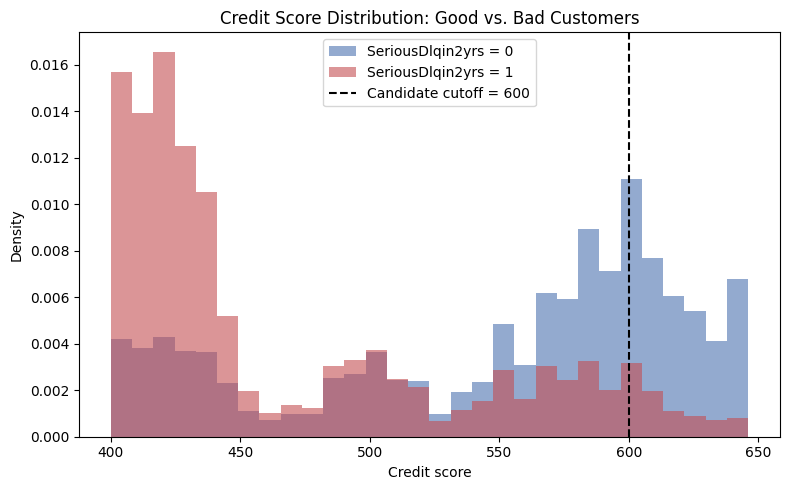

In [33]:
plt.figure(figsize=(8, 5))
# Plot the good (0) and bad (1) customers as two separate, overlapping histograms rather than
# one combined histogram - this is what actually lets us SEE whether the scorecard separates them.
for label, color in [(0, "#4C72B0"), (1, "#C44E52")]:
    subset = full_df.loc[full_df["SeriousDlqin2yrs"] == label, "credit_score"]
    # density=True normalizes each histogram to its own group size, so the two groups
    # are comparable even though there are far more good customers than bad ones.
    plt.hist(subset, bins=30, density=True, alpha=0.6, color=color, label=f"SeriousDlqin2yrs = {label}")

# Mark the 600-point cutoff we're about to test, so we can see visually where it falls
# relative to the two distributions.
plt.axvline(600, color="black", linestyle="--", label="Candidate cutoff = 600")
plt.xlabel("Credit score")
plt.ylabel("Density")
plt.title("Credit Score Distribution: Good vs. Bad Customers")
plt.legend()
plt.tight_layout()
plt.show()


A scorecard is only useful if a cutoff on the score actually separates good and bad customers. We test a 600-point cutoff (matching the base score chosen above) on the **held-out test set only**, so this reflects genuine out-of-sample performance rather than the full population the scorecard was built from.

In [34]:
# Restrict this validation to the TEST rows only - this is the one number in the whole
# notebook that tells us how the finished scorecard performs on data it never touched
# during cleaning, WoE-fitting, or model training.
test_scores = full_df.loc[test_df.index]

CUTOFF = 600
# True/False for every customer: did they score at or above the cutoff?
approved = test_scores["credit_score"] >= CUTOFF

# Group customers into "approved" vs "rejected" and compute each group's actual default rate
validation = test_scores.groupby(approved)["SeriousDlqin2yrs"].agg(["count", "mean"])
validation.columns = ["n_customers", "default_rate"]
validation["default_rate_pct"] = (validation["default_rate"] * 100).round(2)
validation = validation.rename(index={True: "Approved (score >= 600)", False: "Rejected (score < 600)"})

print("Validation on the held-out TEST set (never used to fit WoE, the model, or the scorecard):\n")
print(validation[["n_customers", "default_rate_pct"]])
print(f"\nOverall test-set default rate: {test_scores['SeriousDlqin2yrs'].mean()*100:.2f}%")


Validation on the held-out TEST set (never used to fit WoE, the model, or the scorecard):

                         n_customers  default_rate_pct
credit_score                                          
Rejected (score < 600)         32627              8.72
Approved (score >= 600)        12373              1.31

Overall test-set default rate: 6.68%


**Stage 4 Summary**

At the end of this stage:
- We trained a logistic regression model on WoE features for utilization, age, and income, using the training split only
- We evaluated performance with AUC and an ROC curve on the held-out test set
- We compared five candidate probability cutoffs and picked 0.20 over the untested 0.50 default, since 0.50 never flags a single default in this imbalanced dataset
- We transformed the logistic regression into a scorecard with base points and bin-level points
- Each customer now has a final credit score, and we plotted its distribution split by actual outcome, rather than as a single combined histogram
- We validated a 600-point score cutoff **on the held-out test set**, confirming the scorecard meaningfully separates future default risk rather than just fitting the data it was built from.
